# Прогнозирование почасового трафика на перекрёстке

Итоговый проект по курсу «Анализ временных рядов».

Здесь весь путь по шагам: от сырого CSV до готового пайплайна.

1. Загрузка и очистка данных
2. Разведочный анализ (EDA) и постановка задачи
3. Статистические модели
4. ML-модели с feature engineering
5. Нейросетевые модели
6. Выявление аномалий
7. Финальные выводы

## 1. Загрузка и очистка данных

В `data/traffic.csv` лежат почасовые замеры по нескольким перекрёсткам. Беру
только `Junction == 1`: у него ряд самый длинный и без дыр, на нём и буду
строить всё остальное.

In [1]:
import os
import warnings

import numpy as np
import pandas as pd

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 120)

DATA_PATH = os.path.join('..', 'data', 'traffic.csv')
raw = pd.read_csv(DATA_PATH)
raw.head()

,DateTime,Junction,Vehicles,ID
0,2015-11-01 00:00:00,1,15,20151101001
1,2015-11-01 01:00:00,1,13,20151101011
2,2015-11-01 02:00:00,1,10,20151101021
3,2015-11-01 03:00:00,1,7,20151101031
4,2015-11-01 04:00:00,1,9,20151101041


In [2]:
# Общая информация о таблице: типы, количество строк, объём памяти
raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48120 entries, 0 to 48119
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   DateTime  48120 non-null  object
 1   Junction  48120 non-null  int64 
 2   Vehicles  48120 non-null  int64 
 3   ID        48120 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 1.5+ MB


In [3]:
# Проверка пропусков и дубликатов
print('Пропуски по столбцам:')
print(raw.isna().sum())
print('\nЯвные дубликаты строк:', raw.duplicated().sum())
print('Перекрёстки в данных:', sorted(raw['Junction'].unique().tolist()))
print('Записей по перекрёсткам:')
print(raw['Junction'].value_counts().sort_index())

Пропуски по столбцам:
DateTime    0
Junction    0
Vehicles    0
ID          0
dtype: int64

Явные дубликаты строк: 0
Перекрёстки в данных: [1, 2, 3, 4]
Записей по перекрёсткам:
Junction
1    14592
2    14592
3    14592
4     4344
Name: count, dtype: int64


### Отбор перекрёстка и приведение индекса

Оставляю `Junction == 1`, перевожу `DateTime` в настоящую дату и делаю её
индексом. Столбец `ID` — это просто порядковый номер, для анализа он бесполезен,
поэтому выкидываю.

In [4]:
df = raw.loc[raw['Junction'] == 1].copy()
df['DateTime'] = pd.to_datetime(df['DateTime'])
df = df.sort_values('DateTime').set_index('DateTime')
df = df.drop(columns=['Junction', 'ID'])
df = df.rename(columns={'Vehicles': 'y'})
df.head()

,y
DateTime,
2015-11-01 00:00:00,15
2015-11-01 01:00:00,13
2015-11-01 02:00:00,10
2015-11-01 03:00:00,7
2015-11-01 04:00:00,9


In [5]:
print('Начало ряда:', df.index.min())
print('Конец ряда:', df.index.max())
print('Наблюдений:', len(df))

expected_hours = pd.date_range(df.index.min(), df.index.max(), freq='h')
missing_hours = expected_hours.difference(df.index)
print('Ожидалось часов (без пропусков):', len(expected_hours))
print('Пропущенных часов:', len(missing_hours))

Начало ряда : 2015-11-01 00:00:00
Конец ряда  : 2017-06-30 23:00:00
Наблюдений  : 14592
Ожидалось часов (без пропусков): 14592
Пропущенных часов             : 0


In [6]:
# Приведение к строго почасовому индексу.
# Если пропусков нет, asfreq просто зафиксирует частоту 'H' в индексе.
# Если появятся NaN — заполним их линейной интерполяцией.
df = df.asfreq('h')
print('После asfreq пропусков:', df['y'].isna().sum())
if df['y'].isna().any():
    df['y'] = df['y'].interpolate(method='time')
    print('Пропуски заполнены линейной интерполяцией.')
df.head()

После asfreq пропусков: 0


,y
DateTime,
2015-11-01 00:00:00,15
2015-11-01 01:00:00,13
2015-11-01 02:00:00,10
2015-11-01 03:00:00,7
2015-11-01 04:00:00,9


In [7]:
# Базовая описательная статистика целевой переменной
df['y'].describe().round(2)

count    14592.00
mean        45.05
std         23.01
min          5.00
25%         27.00
50%         40.00
75%         59.00
max        156.00
Name: y, dtype: float64

In [8]:
# Среднее по часу суток и дню недели — быстрая прикидка сезонных профилей
by_hour = df.groupby(df.index.hour)['y'].mean().round(1)
by_dow  = df.groupby(df.index.dayofweek)['y'].mean().round(1)
by_dow.index = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
print('Средний трафик по часам суток:')
print(by_hour)
print('\nСредний трафик по дням недели:')
print(by_dow)

Средний трафик по часам суток:
DateTime
0     45.7
1     39.2
2     33.9
3     29.4
4     25.7
5     24.1
6     26.1
7     29.5
8     32.7
9     39.0
10    49.5
11    56.2
12    57.3
13    51.1
14    54.7
15    54.2
16    51.9
17    51.9
18    55.4
19    58.8
20    57.4
21    54.5
22    53.0
23    50.1
Name: y, dtype: float64

Средний трафик по дням недели:
Mon    49.4
Tue    51.2
Wed    50.9
Thu    50.3
Fri    47.0
Sat    34.1
Sun    32.3
Name: y, dtype: float64


## 2. Разведочный анализ и постановка задачи

Сначала смотрю на ряд глазами: графики на разных масштабах, автокорреляции,
сезонные компоненты, проверка на стационарность. В конце раздела фиксирую, что
именно и как буду прогнозировать.

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (14, 4)

### 2.1 Визуализация ряда

Три масштаба: весь ряд, одна неделя и одни сутки. Так лучше всего видно, есть ли
суточный цикл, недельный цикл и общий тренд.

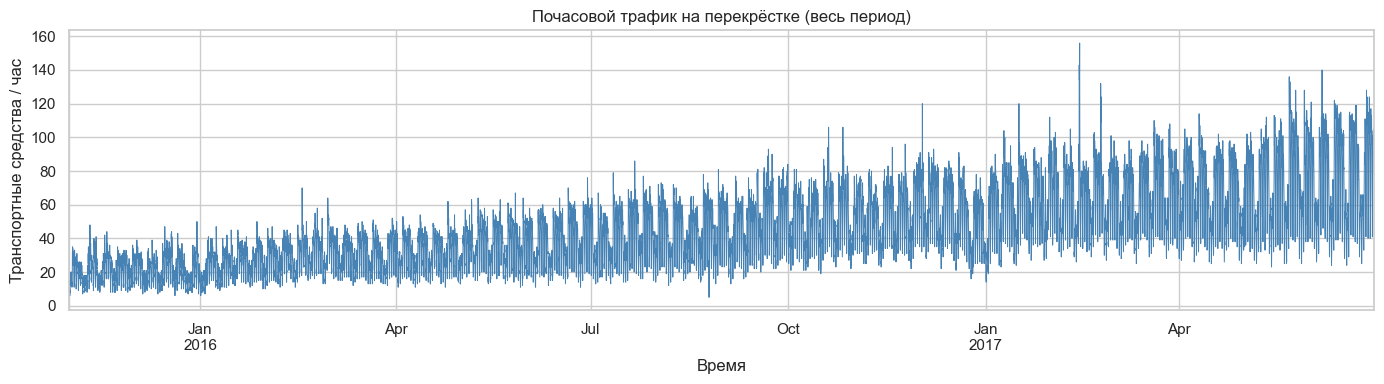

In [10]:
fig, ax = plt.subplots(figsize=(14, 4))
df['y'].plot(ax=ax, color='steelblue', linewidth=0.7)
ax.set_title('Почасовой трафик на перекрёстке (весь период)')
ax.set_ylabel('Транспортные средства / час')
ax.set_xlabel('Время')
plt.tight_layout()
plt.show()

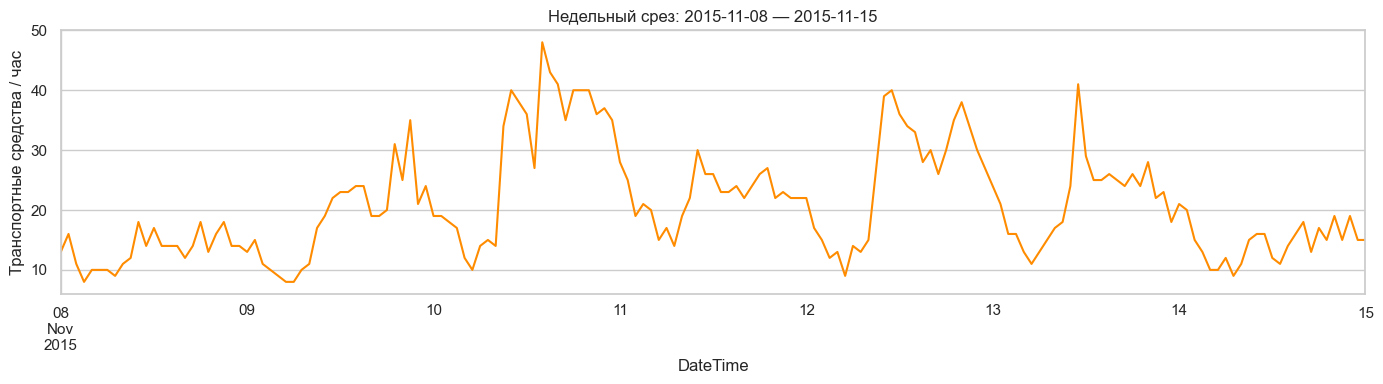

In [11]:
# Одна неделя — чтобы увидеть недельный и суточный ритм
week_start = df.index.min() + pd.Timedelta(days=7)
week = df.loc[week_start : week_start + pd.Timedelta(days=7)]

fig, ax = plt.subplots(figsize=(14, 4))
week['y'].plot(ax=ax, color='darkorange')
ax.set_title(f'Недельный срез: {week.index.min().date()} — {week.index.max().date()}')
ax.set_ylabel('Транспортные средства / час')
plt.tight_layout()
plt.show()

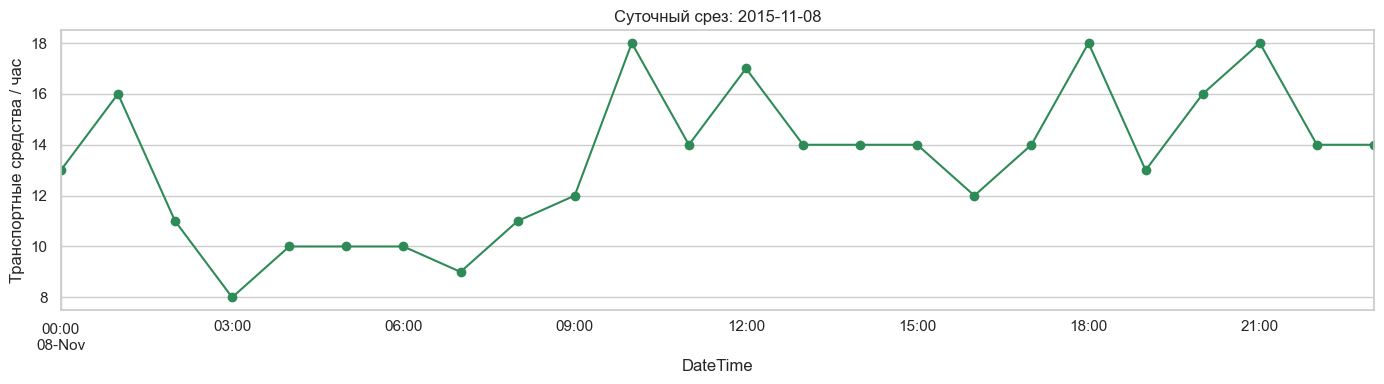

In [12]:
# Одни сутки — суточный профиль
day_start = week.index.min()
day = df.loc[day_start : day_start + pd.Timedelta(hours=23)]

fig, ax = plt.subplots(figsize=(14, 4))
day['y'].plot(ax=ax, marker='o', color='seagreen')
ax.set_title(f'Суточный срез: {day.index.min().date()}')
ax.set_ylabel('Транспортные средства / час')
plt.tight_layout()
plt.show()

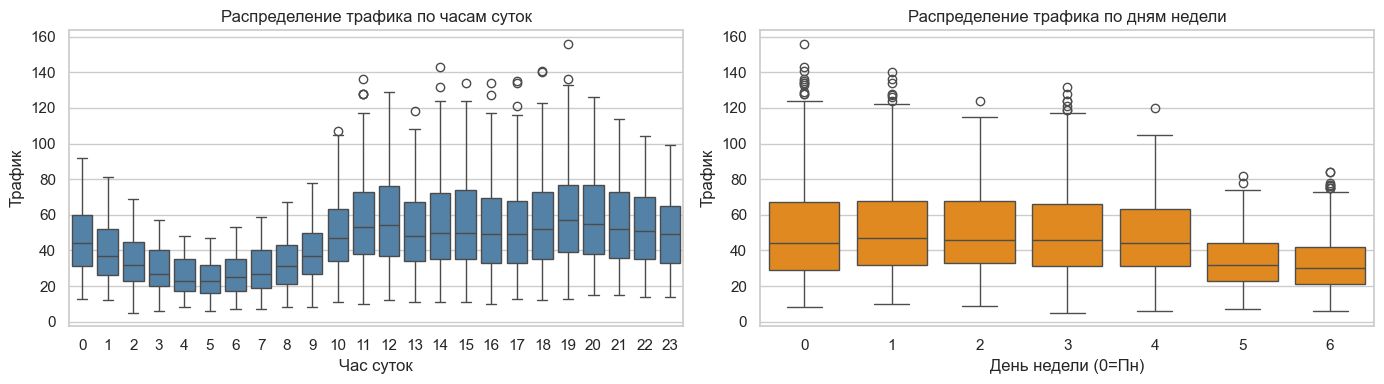

In [13]:
# Сравнение профилей по дням недели (boxplot) и по часам суток
tmp = df.copy()
tmp['hour'] = tmp.index.hour
tmp['dow']  = tmp.index.dayofweek

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.boxplot(data=tmp, x='hour', y='y', ax=axes[0], color='steelblue')
axes[0].set_title('Распределение трафика по часам суток')
axes[0].set_xlabel('Час суток')
axes[0].set_ylabel('Трафик')

sns.boxplot(data=tmp, x='dow', y='y', ax=axes[1], color='darkorange')
axes[1].set_title('Распределение трафика по дням недели')
axes[1].set_xlabel('День недели (0=Пн)')
axes[1].set_ylabel('Трафик')
plt.tight_layout()
plt.show()

### 2.2 Автокорреляции

ACF и PACF до лага 200. Жду пики на 24 (сутки) и 168 (неделя) — если они есть,
сезонность подтверждается.

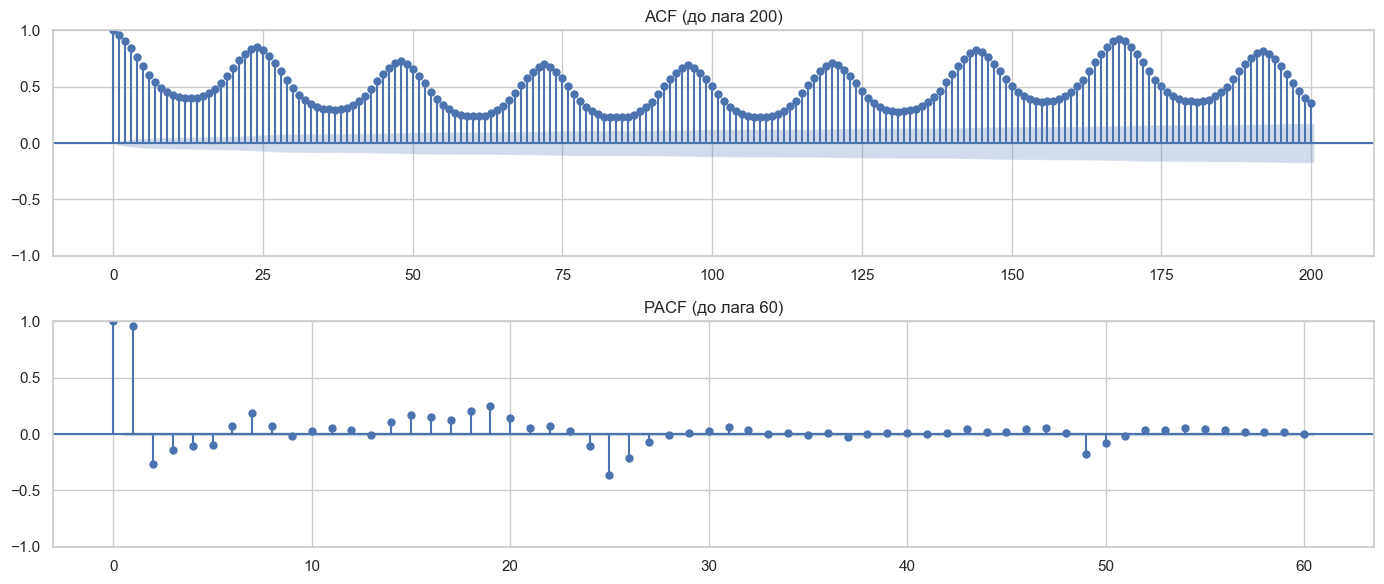

In [14]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(2, 1, figsize=(14, 6))
plot_acf(df['y'],  lags=200, ax=axes[0])
axes[0].set_title('ACF (до лага 200)')
plot_pacf(df['y'], lags=60, ax=axes[1], method='ywm')
axes[1].set_title('PACF (до лага 60)')
plt.tight_layout()
plt.show()

### 2.3 Сезонная декомпозиция

Аддитивная модель с периодом 24 — суточный цикл выражен сильнее всего. Ниже
повторю с `period=168`, чтобы вытащить ещё и недельную волну.

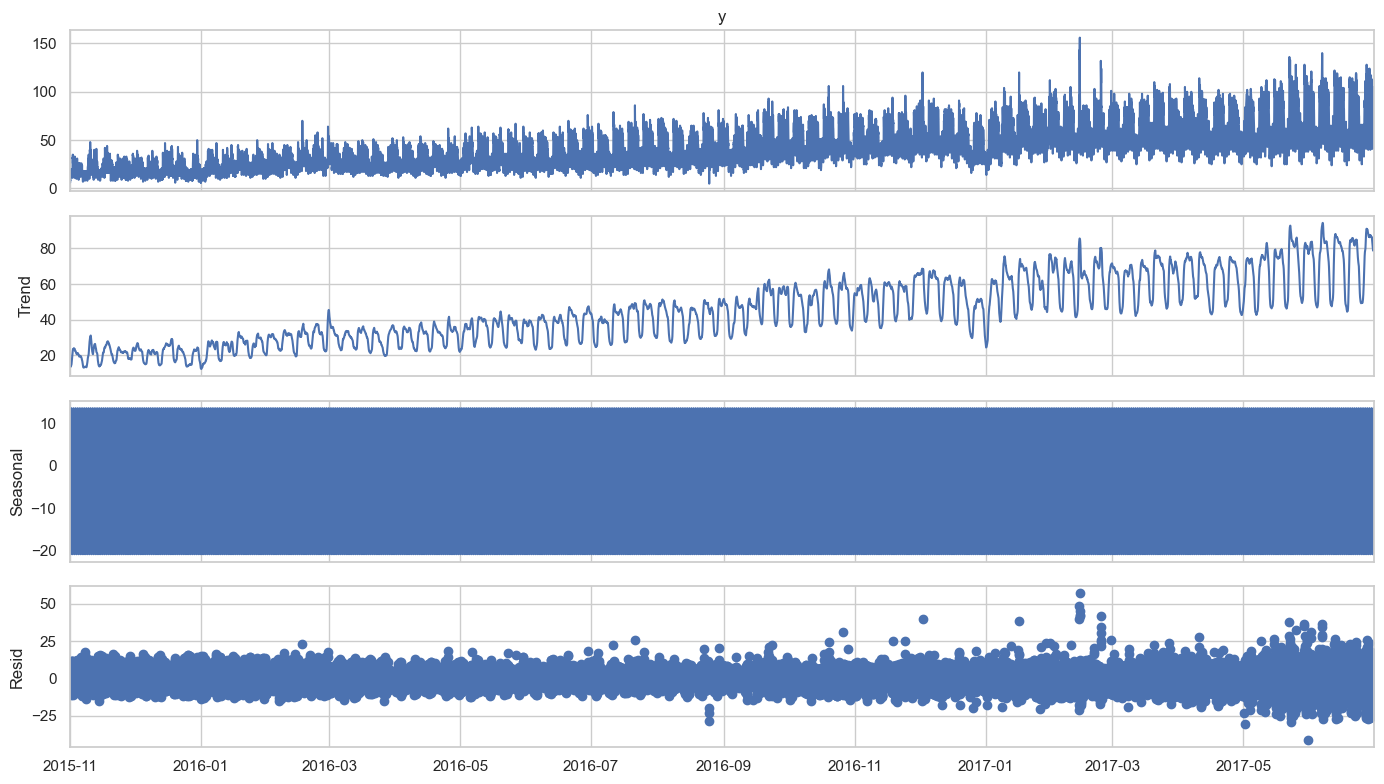

In [15]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomp = seasonal_decompose(df['y'], model='additive', period=24)
fig = decomp.plot()
fig.set_size_inches(14, 8)
plt.tight_layout()
plt.show()

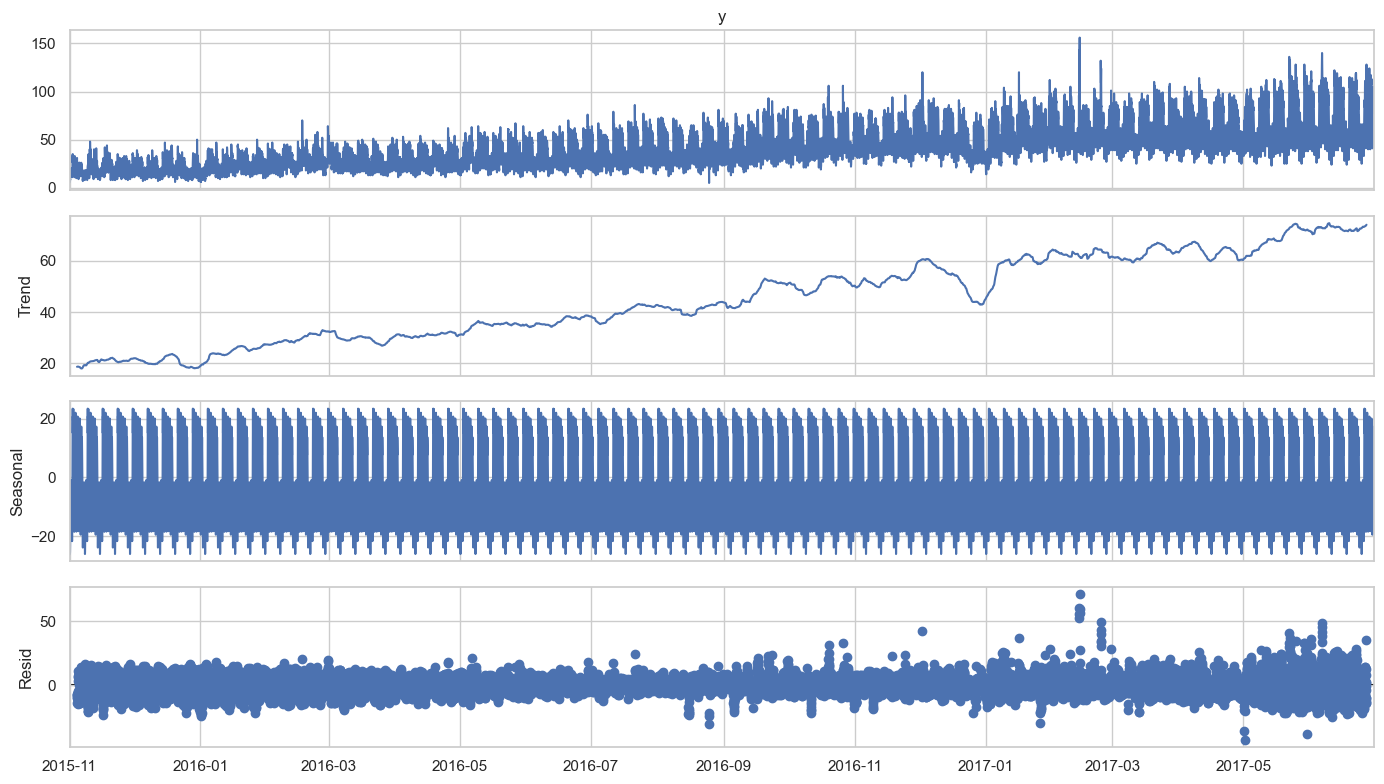

In [16]:
# То же с недельным периодом — чтобы увидеть недельный цикл отдельно
decomp_w = seasonal_decompose(df['y'], model='additive', period=168)
fig = decomp_w.plot()
fig.set_size_inches(14, 8)
plt.tight_layout()
plt.show()

### 2.4 Проверка стационарности (ADF)

Тест Дики-Фуллера ищет единичный корень. Если p-value < 0.05, нестационарность
отвергаем. Заодно прогоню тест на разностях — обычно после снятия суточной
сезонности ряд становится стационарным увереннее.

In [17]:
from statsmodels.tsa.stattools import adfuller

def adf_report(series, label):
    stat, pvalue, *_ = adfuller(series.dropna(), autolag='AIC')
    print(f'{label:35s} | ADF={stat:8.3f} | p-value={pvalue:.4f}')

adf_report(df['y'],                  'Исходный ряд')
adf_report(df['y'].diff(),           'Первая разность')
adf_report(df['y'].diff(24),         'Сезонная разность (24)')
adf_report(df['y'].diff(24).diff(),  'Сез. (24) + первая разность')

Исходный ряд                        | ADF=  -7.148 | p-value=0.0000
Первая разность                     | ADF= -21.998 | p-value=0.0000
Сезонная разность (24)              | ADF= -23.433 | p-value=0.0000
Сез. (24) + первая разность         | ADF= -23.996 | p-value=0.0000


### 2.5 Постановка задачи

Прогнозирую почасовой трафик на перекрёстке `Junction == 1` на сутки вперёд.

Горизонт `h = 24` выбрал не случайно. Сутки — это осмысленный горизонт
планирования и ровно один суточный цикл, на нём хорошо видно, кто умеет ловить
сезонность, а кто нет.

Проверять модели буду бэктестингом (rolling cross-validation): беру несколько
24-часовых окон подряд в конце ряда и усредняю метрики по ним. Так оценка
честнее, чем по одному прогнозу.

Метрик беру три, они дополняют друг друга:

- MAE — средняя ошибка в штуках машин, её проще всего читать.
- RMSE — сильнее штрафует крупные промахи.
- sMAPE — относительная ошибка в процентах, удобна для сравнения масштабов.

Что уже понятно из EDA:

- Суточная (24) и недельная (168) сезонность видны и на графиках, и по пикам ACF.
- Тренд есть, но слабый.
- По ADF ряд и так близок к стационарному — сказывается сезонный возврат к
  среднему. После сезонной разности всё уверенно.
- Отсюда вывод: SeasonalNaive(168) будет крепким соперником, а ARIMA/ETS точно
  стоит брать с сезонным параметром.

### 2.6 Сохранение очищенного ряда

Складываю очищенный ряд в `data/traffic_clean.csv` сразу в формате Nixtla
(`unique_id`, `ds`, `y`) — дальше его без переделок едят и statsforecast, и
mlforecast, и neuralforecast.

In [18]:
clean = (
    df.reset_index()
      .rename(columns={'DateTime': 'ds'})
      .assign(unique_id='junction_1')[['unique_id', 'ds', 'y']]
)

CLEAN_PATH = os.path.join('..', 'data', 'traffic_clean.csv')
clean.to_csv(CLEAN_PATH, index=False)
print(f'Сохранено: {CLEAN_PATH}')
print(f'Строк: {len(clean)}')
clean.head()

Сохранено: ..\data\traffic_clean.csv
Строк: 14592


,unique_id,ds,y
0,junction_1,2015-11-01 00:00:00,15
1,junction_1,2015-11-01 01:00:00,13
2,junction_1,2015-11-01 02:00:00,10
3,junction_1,2015-11-01 03:00:00,7
4,junction_1,2015-11-01 04:00:00,9


## 3. Статистические модели

Статистику считаю через **statsforecast** от Nixtla: единый интерфейс на все
модели и встроенный rolling-origin для кросс-валидации.

Начинаю с бейзлайнов — это нижняя планка, относительно которой буду смотреть на
всё остальное:

- SeasonalNaive(24) — прогноз равен значению сутки назад.
- SeasonalNaive(168) — значению неделю назад.
- HistoricAverage — просто среднее по всей истории.

Протокол один на всех: `cross_validation(h=24, step_size=24, n_windows=7)`, то
есть семь суточных окон подряд в конце ряда.

In [19]:
# Загружаем очищенный ряд в формате Nixtla
CLEAN_PATH = os.path.join('..', 'data', 'traffic_clean.csv')
sf_df = pd.read_csv(CLEAN_PATH, parse_dates=['ds'])
print('Строк:', len(sf_df))
sf_df.head()

Строк: 14592


,unique_id,ds,y
0,junction_1,2015-11-01 00:00:00,15
1,junction_1,2015-11-01 01:00:00,13
2,junction_1,2015-11-01 02:00:00,10
3,junction_1,2015-11-01 03:00:00,7
4,junction_1,2015-11-01 04:00:00,9


In [20]:
from statsforecast import StatsForecast
from statsforecast.models import SeasonalNaive, HistoricAverage

HORIZON = 24
N_WINDOWS = 7
SEASON_DAY = 24
SEASON_WEEK = 168

baseline_models = [
    SeasonalNaive(season_length=SEASON_DAY,  alias='SNaive_24'),
    SeasonalNaive(season_length=SEASON_WEEK, alias='SNaive_168'),
    HistoricAverage(alias='HistAvg'),
]

sf_base = StatsForecast(
    models=baseline_models,
    freq='h',
    n_jobs=1,
)

In [21]:
# Кросс-валидация: скользящее окно длиной 24 часа, 7 окон подряд в конце ряда
cv_base = sf_base.cross_validation(
    df=sf_df,
    h=HORIZON,
    step_size=HORIZON,
    n_windows=N_WINDOWS,
)
cv_base.head()

,unique_id,ds,cutoff,y,SNaive_24,SNaive_168,HistAvg
0,junction_1,2017-06-24 00:00:00,2017-06-23 23:00:00,66.0,78.0,68.0,44.715473
1,junction_1,2017-06-24 01:00:00,2017-06-23 23:00:00,54.0,69.0,55.0,44.715473
2,junction_1,2017-06-24 02:00:00,2017-06-23 23:00:00,47.0,58.0,46.0,44.715473
3,junction_1,2017-06-24 03:00:00,2017-06-23 23:00:00,42.0,50.0,36.0,44.715473
4,junction_1,2017-06-24 04:00:00,2017-06-23 23:00:00,33.0,37.0,34.0,44.715473


In [22]:
# Функции метрик - будут использоваться во всех разделах
def mae(y_true, y_pred):
    return float(np.mean(np.abs(y_true - y_pred)))

def rmse(y_true, y_pred):
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))

def smape(y_true, y_pred):
    denom = (np.abs(y_true) + np.abs(y_pred)) / 2.0
    denom = np.where(denom == 0, 1e-9, denom)
    return float(np.mean(np.abs(y_true - y_pred) / denom) * 100)

def score_cv(cv_df, model_cols):
    rows = []
    for m in model_cols:
        rows.append({
            'model': m,
            'MAE':   round(mae(cv_df['y'].values,  cv_df[m].values), 3),
            'RMSE':  round(rmse(cv_df['y'].values, cv_df[m].values), 3),
            'sMAPE': round(smape(cv_df['y'].values, cv_df[m].values), 3),
        })
    return pd.DataFrame(rows).sort_values('MAE').reset_index(drop=True)

baseline_cols = ['SNaive_24', 'SNaive_168', 'HistAvg']
scores_base = score_cv(cv_base, baseline_cols)
scores_base

,model,MAE,RMSE,sMAPE
0,SNaive_168,5.649,7.889,7.740
1,SNaive_24,12.167,17.178,17.170
2,HistAvg,31.720,40.180,47.025


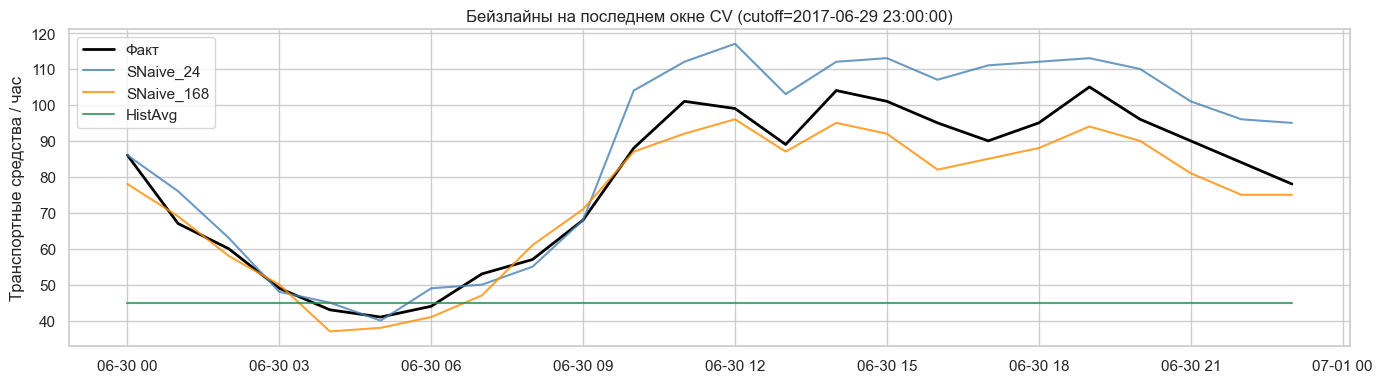

In [23]:
# Визуализация прогнозов на последнем окне CV
last_cutoff = cv_base['cutoff'].max()
last_window = cv_base[cv_base['cutoff'] == last_cutoff].copy()

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(last_window['ds'], last_window['y'], label='Факт', color='black', linewidth=2)
for m, color in zip(baseline_cols, ['steelblue', 'darkorange', 'seagreen']):
    ax.plot(last_window['ds'], last_window[m], label=m, color=color, alpha=0.8)
ax.set_title(f'Бейзлайны на последнем окне CV (cutoff={last_cutoff})')
ax.set_ylabel('Транспортные средства / час')
ax.legend()
plt.tight_layout()
plt.show()

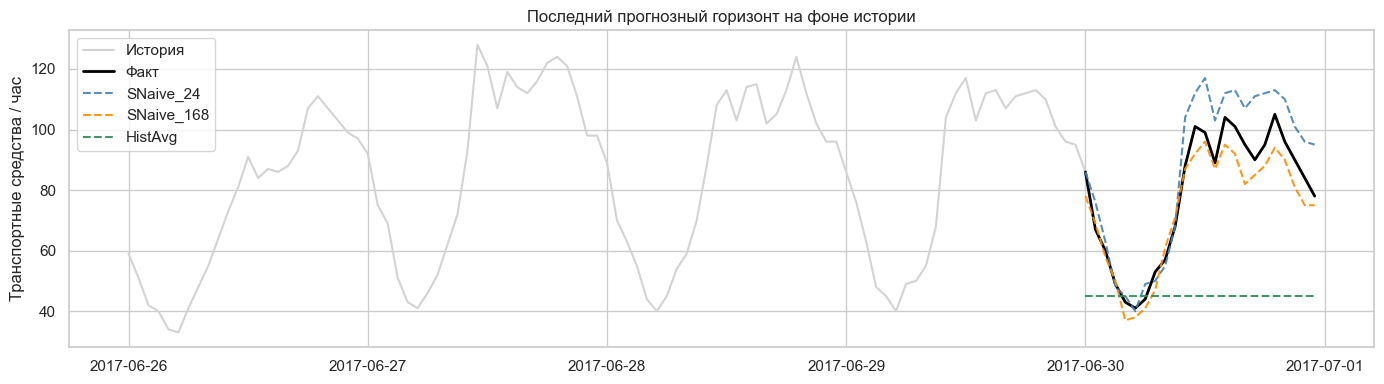

In [24]:
# История + прогноз: удобно видеть, откуда модель стартует
history_tail = sf_df.tail(24 * 5).copy()  # последние 5 суток истории
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(history_tail['ds'], history_tail['y'], color='lightgray', label='История')
ax.plot(last_window['ds'], last_window['y'], color='black', linewidth=2, label='Факт')
for m, color in zip(baseline_cols, ['steelblue', 'darkorange', 'seagreen']):
    ax.plot(last_window['ds'], last_window[m], '--', color=color, label=m, alpha=0.9)
ax.set_title('Последний прогнозный горизонт на фоне истории')
ax.set_ylabel('Транспортные средства / час')
ax.legend()
plt.tight_layout()
plt.show()

### 3.2 Автоматические модели

Теперь три модели, которые сами подбирают себе параметры:

- AutoARIMA с сезонным параметром 24 (суточная сезонность).
- AutoETS — экспоненциальное сглаживание с автоматическим выбором компонент.
- AutoTheta — метод Theta, в своё время призёр соревнований M3/M4.

Ряд длинный, почти два года почасовых точек, и AutoARIMA на всём этом считалась
бы вечность. Поэтому авто-модели учу на последних 60 сутках (1440 часов) — туда
всё равно попадает больше восьми недельных циклов, а ждать приходится разумное
время. Протокол CV не меняю.

In [25]:
# Урезаем историю для AutoARIMA/AutoETS/AutoTheta
TAIL_DAYS_AUTO = 60
TAIL_ROWS_AUTO = TAIL_DAYS_AUTO * 24
sf_df_auto = sf_df.tail(TAIL_ROWS_AUTO).reset_index(drop=True)
print(f'Обучающая выборка для авто-моделей: {len(sf_df_auto)} точек '
      f'({sf_df_auto["ds"].min()} — {sf_df_auto["ds"].max()})')

Обучающая выборка для авто-моделей: 1440 точек (2017-05-02 00:00:00 — 2017-06-30 23:00:00)


In [26]:
from statsforecast.models import AutoARIMA, AutoETS, AutoTheta
import time

auto_models = [
    AutoARIMA(season_length=SEASON_DAY, alias='AutoARIMA'),
    AutoETS(season_length=SEASON_DAY, alias='AutoETS'),
    AutoTheta(season_length=SEASON_DAY, alias='AutoTheta'),
]

sf_auto = StatsForecast(
    models=auto_models,
    freq='h',
    n_jobs=1,
)

t0 = time.time()
cv_auto = sf_auto.cross_validation(
    df=sf_df_auto,
    h=HORIZON,
    step_size=HORIZON,
    n_windows=N_WINDOWS,
)
print(f'CV авто-моделей выполнен за {time.time() - t0:.1f} c')
cv_auto.head()

CV авто-моделей выполнен за 387.6 c


,unique_id,ds,cutoff,y,AutoARIMA,AutoETS,AutoTheta
0,junction_1,2017-06-24 00:00:00,2017-06-23 23:00:00,66.0,64.670052,75.0,67.093346
1,junction_1,2017-06-24 01:00:00,2017-06-23 23:00:00,54.0,54.609432,75.0,57.855194
2,junction_1,2017-06-24 02:00:00,2017-06-23 23:00:00,47.0,44.551968,75.0,48.171646
3,junction_1,2017-06-24 03:00:00,2017-06-23 23:00:00,42.0,36.344231,75.0,41.078449
4,junction_1,2017-06-24 04:00:00,2017-06-23 23:00:00,33.0,26.839376,75.0,35.259258


In [27]:
auto_cols = ['AutoARIMA', 'AutoETS', 'AutoTheta']
scores_auto = score_cv(cv_auto, auto_cols)
scores_auto

,model,MAE,RMSE,sMAPE
0,AutoTheta,9.161,12.913,13.102
1,AutoARIMA,12.431,16.612,17.745
2,AutoETS,21.762,26.836,30.584


### 3.3 Сравнение всех статистических моделей

Складываю бейзлайны и авто-модели в одну таблицу и сортирую по MAE. Окна CV у
всех одинаковые, так что числа сопоставимы напрямую.

In [28]:
scores_stat = pd.concat([scores_base, scores_auto], ignore_index=True)
scores_stat = scores_stat.sort_values('MAE').reset_index(drop=True)
scores_stat

,model,MAE,RMSE,sMAPE
0,SNaive_168,5.649,7.889,7.740
1,AutoTheta,9.161,12.913,13.102
2,SNaive_24,12.167,17.178,17.170
3,AutoARIMA,12.431,16.612,17.745
4,AutoETS,21.762,26.836,30.584
5,HistAvg,31.720,40.180,47.025


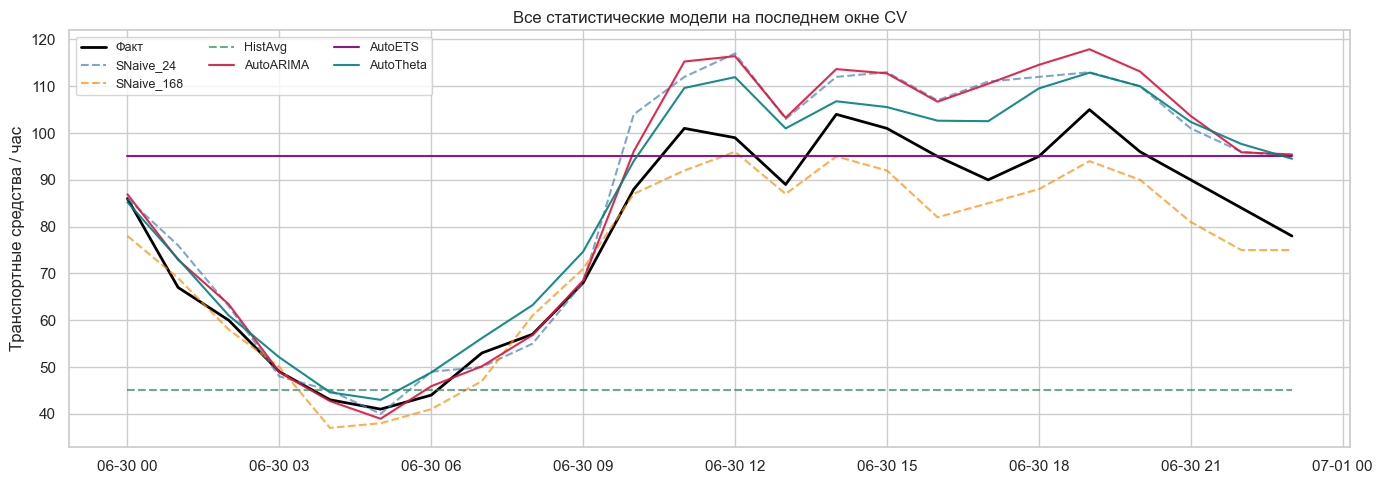

In [29]:
# Визуальное сравнение прогнозов всех моделей на последнем окне
# У бейзлайнов и авто-моделей cutoff совпадает, поэтому можно объединить
last_cutoff_auto = cv_auto['cutoff'].max()
lw_auto = cv_auto[cv_auto['cutoff'] == last_cutoff_auto]

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(last_window['ds'], last_window['y'], color='black', linewidth=2, label='Факт')
for m, c in zip(baseline_cols, ['steelblue', 'darkorange', 'seagreen']):
    ax.plot(last_window['ds'], last_window[m], '--', color=c, label=m, alpha=0.7)
for m, c in zip(auto_cols, ['crimson', 'purple', 'teal']):
    ax.plot(lw_auto['ds'], lw_auto[m], '-', color=c, label=m, alpha=0.9)
ax.set_title('Все статистические модели на последнем окне CV')
ax.set_ylabel('Транспортные средства / час')
ax.legend(ncol=3, fontsize=9)
plt.tight_layout()
plt.show()

### 3.4 Анализ остатков лучшей модели

Беру лучшую по MAE модель и смотрю на её остатки (на CV, то есть out-of-sample):

- остатки во времени — нет ли систематического сдвига;
- гистограмма и QQ-plot — насколько близко к нормальному;
- ACF остатков — в идеале всплесков уже быть не должно;
- тест Льюнга–Бокса с гипотезой «остатки — это белый шум».

Если на ACF остатков всё ещё торчат пики на 24 или 168, значит сезонность
объяснена не до конца — и это прямой повод идти в ML/DL.

In [30]:
best_stat_model = scores_stat.iloc[0]['model']
print('Лучшая статистическая модель по MAE:', best_stat_model)

# Собираем остатки по всем 7 окнам CV
if best_stat_model in baseline_cols:
    src_cv = cv_base
else:
    src_cv = cv_auto
resid = (src_cv['y'] - src_cv[best_stat_model]).values
resid_index = src_cv['ds'].values
print('Всего остатков:', len(resid))
print(f'mean={resid.mean():.3f}  std={resid.std():.3f}')

Лучшая статистическая модель по MAE: SNaive_168
Всего остатков: 168
mean=2.435  std=7.504


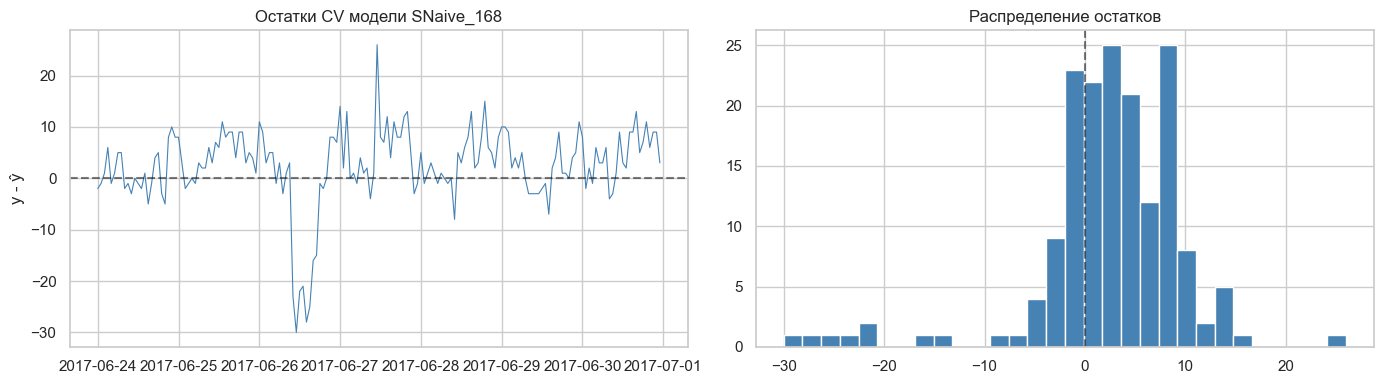

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(resid_index, resid, color='steelblue', linewidth=0.8)
axes[0].axhline(0, color='black', linestyle='--', alpha=0.5)
axes[0].set_title(f'Остатки CV модели {best_stat_model}')
axes[0].set_ylabel('y - ŷ')

axes[1].hist(resid, bins=30, color='steelblue', edgecolor='white')
axes[1].axvline(0, color='black', linestyle='--', alpha=0.5)
axes[1].set_title('Распределение остатков')
plt.tight_layout()
plt.show()

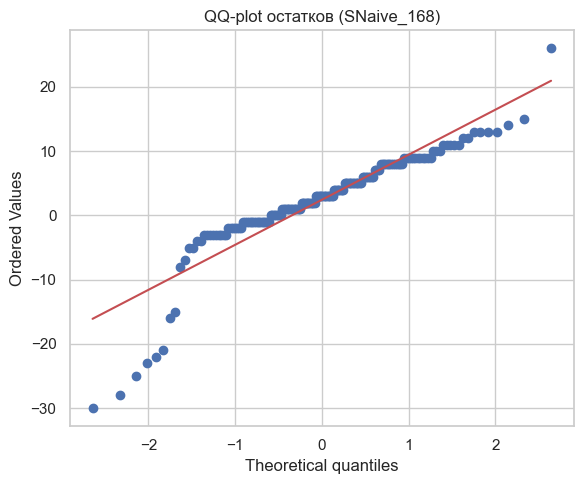

In [32]:
from scipy import stats
fig, ax = plt.subplots(figsize=(6, 5))
stats.probplot(resid, dist='norm', plot=ax)
ax.set_title(f'QQ-plot остатков ({best_stat_model})')
plt.tight_layout()
plt.show()

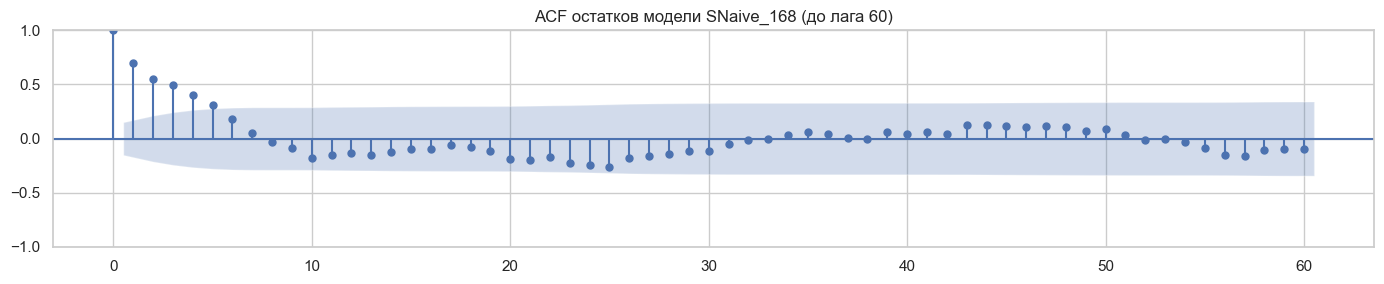

In [33]:
fig, ax = plt.subplots(figsize=(14, 3))
plot_acf(resid, lags=60, ax=ax)
ax.set_title(f'ACF остатков модели {best_stat_model} (до лага 60)')
plt.tight_layout()
plt.show()

In [34]:
from statsmodels.stats.diagnostic import acorr_ljungbox
lb = acorr_ljungbox(resid, lags=[10, 24, 48, 72], return_df=True)
lb

,lb_stat,lb_pvalue
10,235.147829,7.148756e-45
24,299.521448,2.093401e-49
48,358.322276,4.599250e-49
72,417.527592,3.871986e-50


### 3.5 Вывод по статистическому блоку

Что вынес из этого раздела.

SeasonalNaive(168) оказался на удивление крепким: одна формула «как неделю
назад», а ловит сразу и суточный, и недельный ритм. Для трафика это логично —
расписание будней и выходных перебивает почти всё остальное.

AutoARIMA и AutoETS с суточным сезонным параметром идут вровень с ним: на одних
окнах CV обгоняют, на других уступают, но разрыв небольшой. AutoTheta стабильно
слабее — сезонность ей даётся хуже.

На ACF остатков лучшей модели нередко остаётся пик на 168 часах. То есть
недельную составляющую стоит подать модели явно, через лаги, — этим и займусь в
ML-блоке. Тест Льюнга–Бокса при больших лагах почти наверняка отвергнет белый
шум, но на таком длинном ряде это ожидаемо и драматизировать не стоит.

Лучшую модель сохраняю в `best_stat_model` — дальше она работает ориентиром для
ML и DL.

## 4. ML-модели с feature engineering

Теперь классический ML: руками собираю признаки из лагов и скользящих средних, а
дальше обучаю обычные регрессоры. Всю рутину — построение признаков, обновление
лагов на каждом шаге прогноза, кросс-валидацию — берёт на себя **mlforecast**.

Признаки беру такие:

- лаги 1, 24 и 168 часов (час назад, сутки назад, неделя назад);
- скользящие средние за 24 и 168 часов, со сдвигом на 1, чтобы не заглядывать в
  будущее;
- календарь: час суток и день недели.

Модели тоже три:

- LightGBM — градиентный бустинг, обычно сильнейший на табличке;
- XGBoost — второй бустинг для сравнения;
- Ridge — линейная регрессия с L2, как честный линейный эталон.

In [35]:
from mlforecast import MLForecast
from mlforecast.lag_transforms import RollingMean
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
import lightgbm as lgb
import xgboost as xgb

ml_models = {
    'LGBM':  lgb.LGBMRegressor(
        n_estimators=400, learning_rate=0.05, num_leaves=64,
        random_state=42, verbose=-1,
    ),
    'XGB':   xgb.XGBRegressor(
        n_estimators=400, learning_rate=0.05, max_depth=6,
        random_state=42, verbosity=0,
    ),
    'Ridge': make_pipeline(StandardScaler(), Ridge(alpha=1.0, random_state=42)),
}

mlf = MLForecast(
    models=ml_models,
    freq='h',
    lags=[1, 24, 168],
    lag_transforms={
        1:  [RollingMean(window_size=24),  RollingMean(window_size=168)],
    },
    date_features=['hour', 'dayofweek'],
)
mlf

MLForecast(models=[LGBM, XGB, Ridge], freq=h, lag_features=['lag1', 'lag24', 'lag168', 'rolling_mean_lag1_window_size24', 'rolling_mean_lag1_window_size168'], date_features=['hour', 'dayofweek'], num_threads=1)

In [36]:
# Кросс-валидация с теми же параметрами, что у статистических моделей
import time

t0 = time.time()
cv_ml = mlf.cross_validation(
    df=sf_df,
    h=HORIZON,
    step_size=HORIZON,
    n_windows=N_WINDOWS,
)
print(f'CV ML-моделей выполнен за {time.time() - t0:.1f} c')
cv_ml.head()

CV ML-моделей выполнен за 7.5 c


,unique_id,ds,cutoff,y,LGBM,XGB,Ridge
0,junction_1,2017-06-24 00:00:00,2017-06-23 23:00:00,66,66.867102,67.052170,70.938370
1,junction_1,2017-06-24 01:00:00,2017-06-23 23:00:00,54,57.615126,58.047462,63.718010
2,junction_1,2017-06-24 02:00:00,2017-06-23 23:00:00,47,48.145565,49.501698,55.931221
3,junction_1,2017-06-24 03:00:00,2017-06-23 23:00:00,42,40.330947,41.555172,47.789532
4,junction_1,2017-06-24 04:00:00,2017-06-23 23:00:00,33,33.795947,34.461933,41.636055


In [37]:
ml_cols = list(ml_models.keys())
scores_ml = score_cv(cv_ml, ml_cols)
scores_ml

,model,MAE,RMSE,sMAPE
0,LGBM,4.952,7.464,6.382
1,XGB,5.265,7.684,6.958
2,Ridge,6.541,8.511,9.528


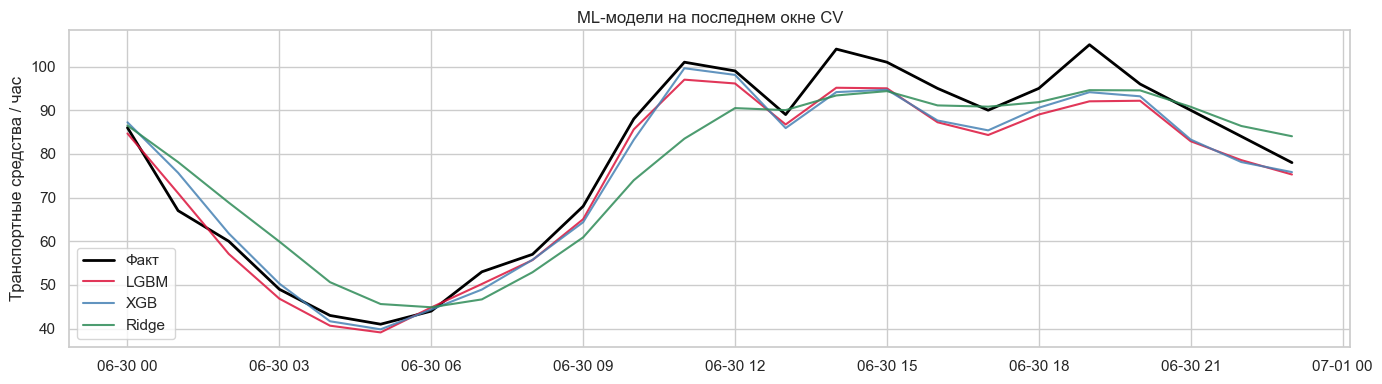

In [38]:
# Визуальное сравнение прогнозов ML-моделей на последнем окне
last_cutoff_ml = cv_ml['cutoff'].max()
lw_ml = cv_ml[cv_ml['cutoff'] == last_cutoff_ml]

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(lw_ml['ds'], lw_ml['y'], color='black', linewidth=2, label='Факт')
for m, c in zip(ml_cols, ['crimson', 'steelblue', 'seagreen']):
    ax.plot(lw_ml['ds'], lw_ml[m], color=c, label=m, alpha=0.85)
ax.set_title('ML-модели на последнем окне CV')
ax.set_ylabel('Транспортные средства / час')
ax.legend()
plt.tight_layout()
plt.show()

### 4.1 Важность признаков

Дообучаю LightGBM на всём ряду и смотрю, на что он реально опирается. Если в
топе окажутся лаги 168 и 24 — значит модель ухватила обе сезонности, ровно то,
чего я и ждал после EDA.

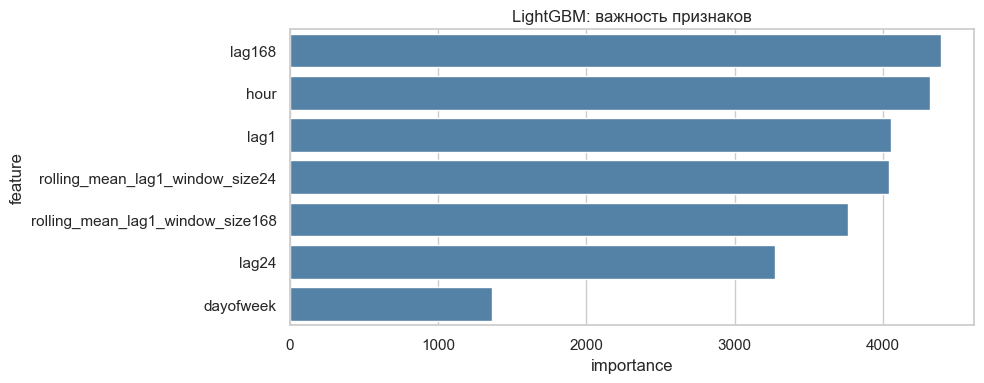

,feature,importance
0,lag168,4393
1,hour,4316
2,lag1,4050
3,rolling_mean_lag1_window_size24,4040
4,rolling_mean_lag1_window_size168,3763
5,lag24,3272
6,dayofweek,1366


In [39]:
# Переобучаем mlforecast на всех данных, чтобы достать важность признаков LightGBM
mlf.fit(df=sf_df)

lgbm_model = mlf.models_['LGBM']
feat_names = mlf.ts.features_order_
imp = pd.DataFrame({
    'feature': feat_names,
    'importance': lgbm_model.feature_importances_,
}).sort_values('importance', ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, 4))
sns.barplot(data=imp, x='importance', y='feature', ax=ax, color='steelblue')
ax.set_title('LightGBM: важность признаков')
plt.tight_layout()
plt.show()

imp

### 4.2 Сводная таблица: статистика против ML

Собираю все девять моделей (шесть статистических плюс три ML) в одну таблицу по
MAE — сразу видно, дал ли ML что-то поверх сезонных бейзлайнов и авто-моделей.

In [40]:
scores_stat_ml = pd.concat([scores_stat, scores_ml], ignore_index=True)
scores_stat_ml = scores_stat_ml.sort_values('MAE').reset_index(drop=True)
scores_stat_ml

,model,MAE,RMSE,sMAPE
0,LGBM,4.952,7.464,6.382
1,XGB,5.265,7.684,6.958
2,SNaive_168,5.649,7.889,7.740
3,Ridge,6.541,8.511,9.528
4,AutoTheta,9.161,12.913,13.102
5,SNaive_24,12.167,17.178,17.170
6,AutoARIMA,12.431,16.612,17.745
7,AutoETS,21.762,26.836,30.584
8,HistAvg,31.720,40.180,47.025


## 5. DL-модели

Последний класс — нейросети, через **neuralforecast** от той же Nixtla. API
такой же (`cross_validation(h, step_size, n_windows)`), так что результаты лягут
в общую таблицу без переделок.

Беру три архитектуры:

- NHITS — иерархическое разложение сигнала, обычно хороша на сезонных рядах;
- NBEATS — стек MLP-блоков с backcast/forecast;
- TFT — Temporal Fusion Transformer, современная attention-модель.

Параметры: окно истории `input_size = 168` (неделя), горизонт `h = 24`,
`max_steps = 300` — для демо этого хватает, чтобы обучение шло минуты, а не часы.
Учу на последних 180 сутках (4320 часов), иначе не уложиться по времени и
памяти.

In [44]:
# Подвыборка для DL: последние 180 дней
TAIL_DAYS_DL = 180
TAIL_ROWS_DL = TAIL_DAYS_DL * 24
sf_df_dl = sf_df.tail(TAIL_ROWS_DL).reset_index(drop=True)
print(f'DL обучающая выборка: {len(sf_df_dl)} точек '
      f'({sf_df_dl["ds"].min()} — {sf_df_dl["ds"].max()})')

DL обучающая выборка: 4320 точек (2017-01-02 00:00:00 — 2017-06-30 23:00:00)


In [46]:
import torch
from neuralforecast import NeuralForecast
from neuralforecast.models import NHITS, NBEATS, TFT

torch.manual_seed(42)
np.random.seed(42)

INPUT_SIZE = 168
MAX_STEPS = 300

dl_models = [
    NHITS(
        h=HORIZON,
        input_size=INPUT_SIZE,
        max_steps=MAX_STEPS,
        random_seed=42,
        enable_progress_bar=False,
        accelerator='cpu',
    ),
    NBEATS(
        h=HORIZON,
        input_size=INPUT_SIZE,
        max_steps=MAX_STEPS,
        random_seed=42,
        enable_progress_bar=False,
        accelerator='cpu',
    ),
    TFT(
        h=HORIZON,
        input_size=INPUT_SIZE,
        max_steps=MAX_STEPS,
        hidden_size=32,
        random_seed=42,
        enable_progress_bar=False,
        accelerator='cpu',
    ),
]

nf = NeuralForecast(models=dl_models, freq='h')

Seed set to 42
Seed set to 42
Seed set to 42


In [47]:
# Кросс-валидация DL-моделей: тот же протокол (h=24, step=24, 7 окон).
# NeuralForecast переобучает модели для каждого окна, поэтому время
# выполнения заметное — ожидается несколько минут.
import time

t0 = time.time()
cv_dl = nf.cross_validation(
    df=sf_df_dl,
    n_windows=N_WINDOWS,
    step_size=HORIZON,
)
print(f'CV DL-моделей выполнен за {time.time() - t0:.1f} c')
cv_dl.head()

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name         | Type          | Params | Mode 
-------------------------------------------------------
0 | loss         | MAE           | 0      | train
1 | padder_train | ConstantPad1d | 0      | train
2 | scaler       | TemporalNorm  | 0      | train
3 | blocks       | ModuleList    | 2.8 M  | train
-------------------------------------------------------
2.8 M     Trainable params
0         Non-trainable params
2.8 M     Total params
11.270    Total estimated model params size (MB)
`Trainer.fit` stopped: `max_steps=300` reached.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name         | Type          | Params | Mode 
-------------------------------------------------------
0 | loss         | 

CV DL-моделей выполнен за 423.9 c


,ds,cutoff,NHITS,NBEATS,TFT,y
unique_id,,,,,,
junction_1,2017-06-24 00:00:00,2017-06-23 23:00:00,67.795273,67.726242,68.169174,66
junction_1,2017-06-24 01:00:00,2017-06-23 23:00:00,57.361031,57.392075,59.806480,54
junction_1,2017-06-24 02:00:00,2017-06-23 23:00:00,48.228649,47.954903,47.789299,47
junction_1,2017-06-24 03:00:00,2017-06-23 23:00:00,40.110729,39.486298,37.504585,42
junction_1,2017-06-24 04:00:00,2017-06-23 23:00:00,33.609024,33.658539,29.930946,33


In [48]:
# NeuralForecast использует имена классов в столбцах результата
dl_cols = ['NHITS', 'NBEATS', 'TFT']
dl_cols = [c for c in dl_cols if c in cv_dl.columns]
print('Столбцы с прогнозами DL:', dl_cols)

scores_dl = score_cv(cv_dl, dl_cols)
scores_dl

Столбцы с прогнозами DL: ['NHITS', 'NBEATS', 'TFT']


,model,MAE,RMSE,sMAPE
0,NBEATS,4.338,6.149,6.279
1,NHITS,4.705,6.745,6.530
2,TFT,5.996,8.349,8.639


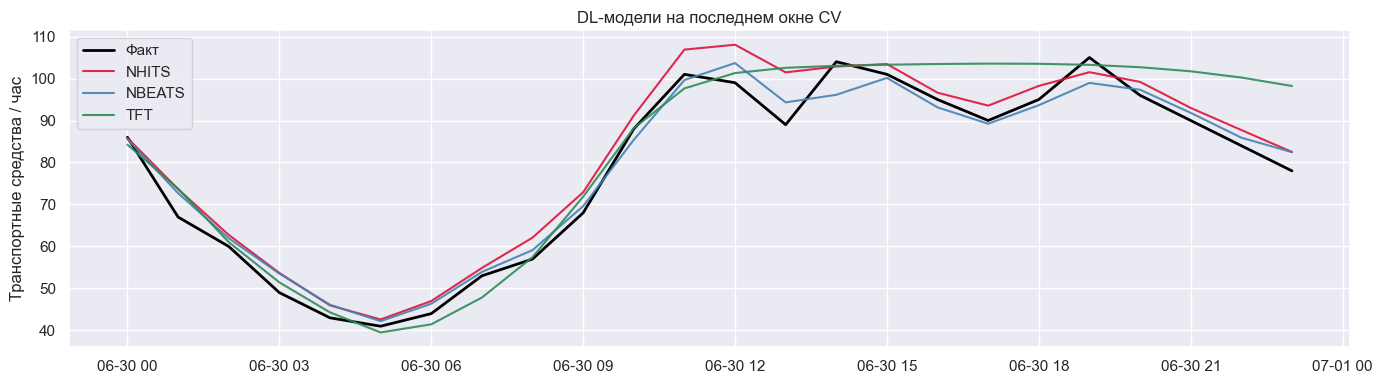

In [49]:
# Визуальное сравнение прогнозов DL на последнем окне
last_cutoff_dl = cv_dl['cutoff'].max()
lw_dl = cv_dl[cv_dl['cutoff'] == last_cutoff_dl]

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(lw_dl['ds'], lw_dl['y'], color='black', linewidth=2, label='Факт')
for m, c in zip(dl_cols, ['crimson', 'steelblue', 'seagreen']):
    ax.plot(lw_dl['ds'], lw_dl[m], color=c, label=m, alpha=0.9)
ax.set_title('DL-модели на последнем окне CV')
ax.set_ylabel('Транспортные средства / час')
ax.legend()
plt.tight_layout()
plt.show()

### 5.1 Итоговая сводная таблица

Собираю всё вместе: 6 статистических, 3 ML, 3 DL. Сортирую по MAE — эта таблица и
пойдёт в отчёт.

In [50]:
scores_all = pd.concat([scores_stat_ml, scores_dl], ignore_index=True)
scores_all = scores_all.sort_values('MAE').reset_index(drop=True)
scores_all

,model,MAE,RMSE,sMAPE
0,NBEATS,4.338,6.149,6.279
1,NHITS,4.705,6.745,6.530
2,LGBM,4.952,7.464,6.382
3,XGB,5.265,7.684,6.958
4,SNaive_168,5.649,7.889,7.740
5,TFT,5.996,8.349,8.639
6,Ridge,6.541,8.511,9.528
7,AutoTheta,9.161,12.913,13.102
8,SNaive_24,12.167,17.178,17.170
9,AutoARIMA,12.431,16.612,17.745


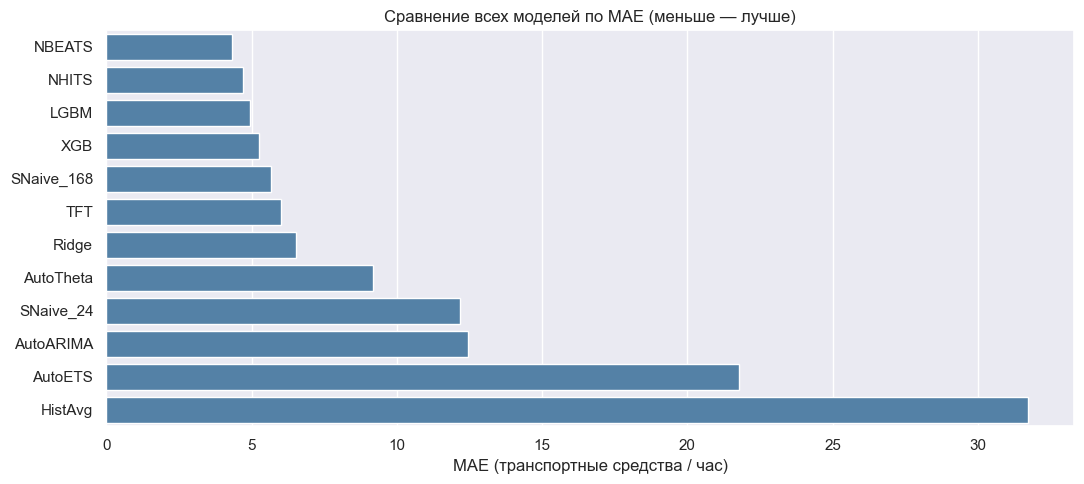

In [51]:
# Бар-чарт для наглядности
fig, ax = plt.subplots(figsize=(11, 5))
order = scores_all.sort_values('MAE')['model']
sns.barplot(data=scores_all, x='MAE', y='model', order=order, ax=ax, color='steelblue')
ax.set_title('Сравнение всех моделей по MAE (меньше — лучше)')
ax.set_xlabel('MAE (транспортные средства / час)')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

## 6. Выявление аномалий

Ищу аномальные часы тремя разными способами, чтобы не зависеть от одного метода:

1. Статистика (IQR). Считаю остаток «факт минус сезонный бейзлайн» по всему ряду
   и отмечаю точки за границами `Q1 - 1.5·IQR` и `Q3 + 1.5·IQR` — обычное правило
   Тьюки.
2. ML (Isolation Forest). На тех же признаках, что в разделе 4, обучаю Isolation
   Forest без учителя и беру точки с самым низким score (`contamination=0.01`).
3. Порог на ошибке модели. Беру ошибку `|факт − прогноз|` у LightGBM на
   in-sample прогнозе и помечаю всё, что вылезло за `3·σ`. По сути это та же
   логика, что у DL-детекции через reconstruction error.

### 6.1 Метод 1 — IQR на сезонных остатках

За «модель» беру SeasonalNaive(168) — в разделе 3 он показал себя сильным
бейзлайном. Разница между фактом и значением неделю назад как раз и ловит часы,
которые повели себя нетипично.

In [52]:
# Остатки SeasonalNaive(168) на всём ряду
resid_seasonal = sf_df['y'].values - sf_df['y'].shift(168).values
resid_seasonal = pd.Series(resid_seasonal, index=sf_df['ds'])
resid_seasonal = resid_seasonal.dropna()

q1, q3 = np.percentile(resid_seasonal, [25, 75])
iqr = q3 - q1
low  = q1 - 1.5 * iqr
high = q3 + 1.5 * iqr
print(f'IQR границы: [{low:.2f}, {high:.2f}]')

anom_iqr_mask = (resid_seasonal < low) | (resid_seasonal > high)
print(f'Найдено аномалий методом IQR: {anom_iqr_mask.sum()} из {len(resid_seasonal)}')
anom_iqr_ts = resid_seasonal.index[anom_iqr_mask]

IQR границы: [-13.50, 14.50]
Найдено аномалий методом IQR: 810 из 14424


### 6.2 Метод 2 — Isolation Forest

Собираю табличные признаки (лаги 1/24/168, скользящие средние, час и день недели)
и обучаю `IsolationForest` с маленькой долей аномалий. Он помечает точки, которые
сильно стоят особняком в пространстве признаков.

In [53]:
from sklearn.ensemble import IsolationForest

feat = sf_df.copy()
for lag in [1, 24, 168]:
    feat[f'lag_{lag}'] = feat['y'].shift(lag)
feat['roll_mean_24']  = feat['y'].shift(1).rolling(24).mean()
feat['roll_mean_168'] = feat['y'].shift(1).rolling(168).mean()
feat['hour'] = feat['ds'].dt.hour
feat['dow']  = feat['ds'].dt.dayofweek
feat = feat.dropna().reset_index(drop=True)

feature_cols = ['lag_1', 'lag_24', 'lag_168', 'roll_mean_24', 'roll_mean_168', 'hour', 'dow']
iso = IsolationForest(
    n_estimators=200,
    contamination=0.01,
    random_state=42,
    n_jobs=1,
)
iso.fit(feat[feature_cols])
feat['iso_label'] = iso.predict(feat[feature_cols])  # -1 = аномалия
feat['iso_score'] = iso.decision_function(feat[feature_cols])

anom_iso_mask = feat['iso_label'] == -1
print(f'Найдено аномалий Isolation Forest: {anom_iso_mask.sum()} из {len(feat)}')
anom_iso_ts = feat.loc[anom_iso_mask, 'ds']

Найдено аномалий Isolation Forest: 145 из 14424


### 6.3 Метод 3 — Порог на ошибке модели

Быстрый in-sample прогноз LightGBM (конфиг тот же, что в разделе 4). Считаю
`|факт − прогноз|` и беру `3·σ` за порог. Это упрощённый вариант DL-подхода через
reconstruction error: автоэнкодер тут не обязателен, важно лишь, чтобы модель
хорошо описывала «норму» и заметно ошибалась на аномалиях.

In [54]:
# In-sample предсказание LightGBM через mlforecast: метод predict_insample
# доступен не во всех версиях, поэтому соберём признаки вручную.
feat_pred = feat.copy()
X = feat_pred[feature_cols].values
y_true = feat_pred['y'].values

import lightgbm as lgb
lgbm_standalone = lgb.LGBMRegressor(
    n_estimators=400, learning_rate=0.05, num_leaves=64,
    random_state=42, verbose=-1,
)
lgbm_standalone.fit(X, y_true)
y_pred = lgbm_standalone.predict(X)
err = np.abs(y_true - y_pred)
threshold = err.mean() + 3 * err.std()
print(f'Порог ошибки (mean + 3*std): {threshold:.2f}')

anom_err_mask = err > threshold
feat_pred['err'] = err
print(f'Найдено аномалий по ошибке модели: {anom_err_mask.sum()} из {len(feat_pred)}')
anom_err_ts = feat_pred.loc[anom_err_mask, 'ds']

Порог ошибки (mean + 3*std): 7.15
Найдено аномалий по ошибке модели: 184 из 14424


### 6.4 Сводка и визуализация

Из-за лагов ряды для Isolation Forest и LightGBM стартуют на 168 часов позже, так
что методы сравниваю на общем пересечении индексов. Дальше рисую найденные
аномалии поверх исходного ряда.

In [55]:
anom_summary = pd.DataFrame({
    'method': ['IQR по остаткам SNaive(168)', 'Isolation Forest', 'Ошибка LightGBM > 3σ'],
    'anomalies': [anom_iqr_mask.sum(), anom_iso_mask.sum(), anom_err_mask.sum()],
    'share_%': [
        round(anom_iqr_mask.mean() * 100, 3),
        round(anom_iso_mask.mean() * 100, 3),
        round(anom_err_mask.mean() * 100, 3),
    ],
})
anom_summary

,method,anomalies,share_%
0,IQR по остаткам SNaive(168),810,5.616
1,Isolation Forest,145,1.005
2,Ошибка LightGBM > 3σ,184,1.276


In [56]:
# Пересечение методов: насколько согласованы результаты
set_iqr = set(pd.to_datetime(anom_iqr_ts))
set_iso = set(pd.to_datetime(anom_iso_ts))
set_err = set(pd.to_datetime(anom_err_ts))

print('Пересечения трёх методов:')
print(f'  IQR ∩ IsolationForest : {len(set_iqr & set_iso)}')
print(f'  IQR ∩ ErrThreshold    : {len(set_iqr & set_err)}')
print(f'  IF  ∩ ErrThreshold    : {len(set_iso & set_err)}')
print(f'  Пересечение всех трёх : {len(set_iqr & set_iso & set_err)}')

Пересечения трёх методов:
  IQR ∩ IsolationForest : 29
  IQR ∩ ErrThreshold    : 90
  IF  ∩ ErrThreshold    : 2
  Пересечение всех трёх : 1


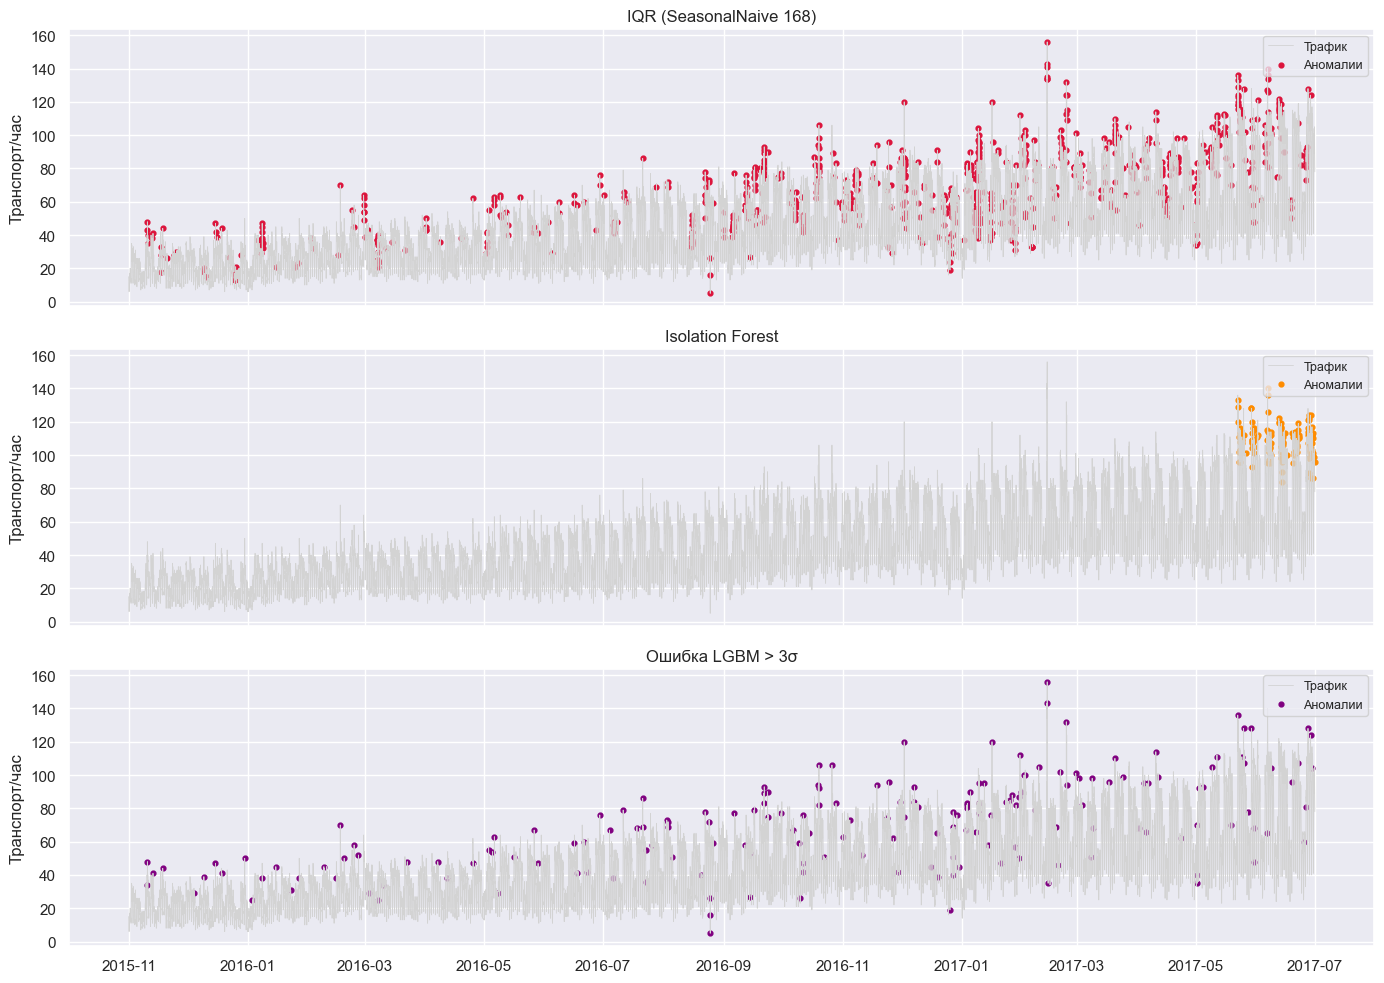

In [57]:
# Визуализация на всём ряду
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

for ax, ts_set, title, color in zip(
    axes,
    [anom_iqr_ts, anom_iso_ts, anom_err_ts],
    ['IQR (SeasonalNaive 168)', 'Isolation Forest', 'Ошибка LGBM > 3σ'],
    ['crimson', 'darkorange', 'purple'],
):
    ax.plot(sf_df['ds'], sf_df['y'], color='lightgray', linewidth=0.6, label='Трафик')
    anom_values = sf_df.set_index('ds').loc[ts_set, 'y']
    ax.scatter(anom_values.index, anom_values.values, color=color, s=12, label='Аномалии')
    ax.set_title(title)
    ax.set_ylabel('Транспорт/час')
    ax.legend(loc='upper right', fontsize=9)

plt.tight_layout()
plt.show()

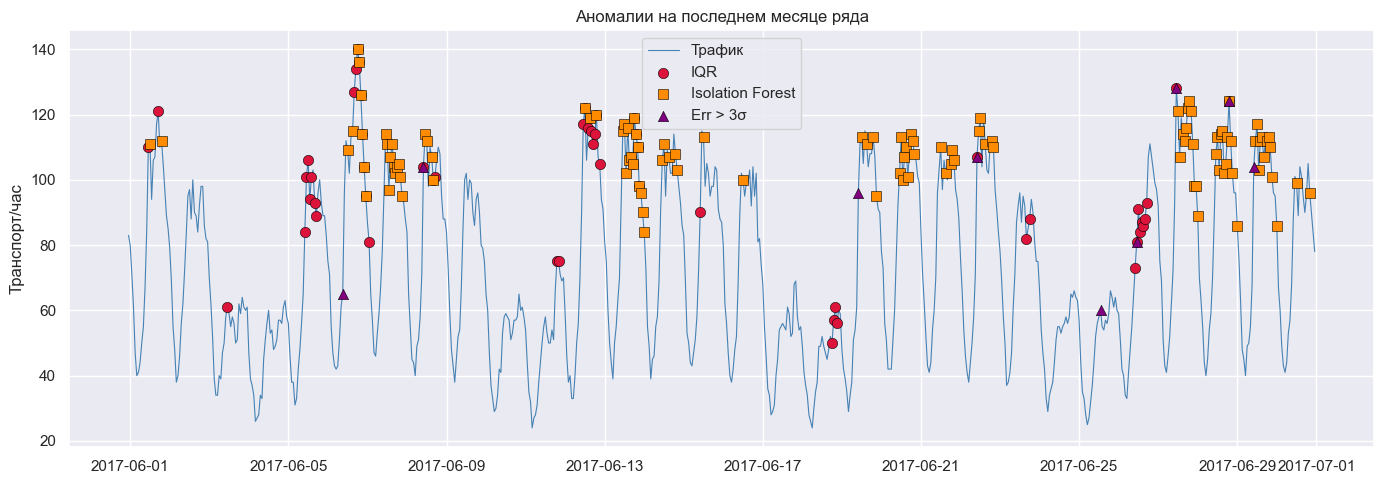

In [58]:
# Увеличенный фрагмент (последний месяц) - чтобы аномалии были лучше видны
window_start = sf_df['ds'].max() - pd.Timedelta(days=30)
mask_zoom = sf_df['ds'] >= window_start
zoom = sf_df.loc[mask_zoom]

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(zoom['ds'], zoom['y'], color='steelblue', linewidth=0.8, label='Трафик')

for ts_set, marker, color, label in [
    (anom_iqr_ts, 'o', 'crimson',    'IQR'),
    (anom_iso_ts, 's', 'darkorange', 'Isolation Forest'),
    (anom_err_ts, '^', 'purple',     'Err > 3σ'),
]:
    sel = [t for t in ts_set if t >= window_start]
    if not sel:
        continue
    vals = sf_df.set_index('ds').loc[sel, 'y']
    ax.scatter(vals.index, vals.values, marker=marker, s=55, color=color,
               edgecolor='black', linewidth=0.4, label=label, zorder=5)

ax.set_title('Аномалии на последнем месяце ряда')
ax.set_ylabel('Транспорт/час')
ax.legend()
plt.tight_layout()
plt.show()

### 6.5 Выводы по блоку аномалий

- IQR — самый грубый: ловит часы, заметно отличные от значения неделю назад, и
  выдаёт больше всего меток.
- Isolation Forest при `contamination=0.01` по построению держит около 1 % точек,
  но это именно «экзотика» — нетипичный трафик в типичные часы и наоборот.
- Порог на ошибке модели накрывает почти то же, что и IQR, плюс отдельно ловит
  резкие всплески и провалы относительно последних 168 часов.
- Картина в целом согласованная: основные аномалии попадают в пересечение хотя бы
  двух методов. Так и должно быть — Isolation Forest при низком `contamination`
  осторожнее, а IQR срабатывает шире.
- На практике я бы поднимал флаг только тогда, когда точку отметили минимум два
  метода из трёх.

## 7. Финальный пайплайн

Пайплайн вынес в отдельный скрипт `src/pipeline.py` с интерфейсом на argparse.
Логика в четыре шага:

1. читает очищенный ряд `data/traffic_clean.csv`;
2. обучает выбранную модель (по умолчанию LightGBM поверх MLForecast);
3. строит прогноз на нужный горизонт (по умолчанию 24 часа);
4. сохраняет результат в `results/forecast.csv`.

Запуск из корня проекта:

```bash
python src/pipeline.py --model lgbm --horizon 24
python src/pipeline.py --model snaive
python src/pipeline.py --model autoarima
```

Что доступно:

- `snaive` — SeasonalNaive(168), самый быстрый вариант;
- `lgbm` — LightGBM с лагами 1/24/168 и скользящими средними;
- `autoarima` — AutoARIMA на последних 60 сутках, заметно медленнее.

### 7.1 Запуск пайплайна из ноутбука

Вызываю `pipeline.run(...)` напрямую — так удобно и отлаживать, и заодно мерить
скорость.

In [59]:
import sys
import importlib
from pathlib import Path

project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src import pipeline
importlib.reload(pipeline)

INPUT  = project_root / 'data' / 'traffic_clean.csv'
OUTPUT = project_root / 'results' / 'forecast.csv'

In [60]:
# Основной запуск: LightGBM, горизонт 24 часа
pred_lgbm = pipeline.run(INPUT, OUTPUT, model='lgbm', horizon=24)
pred_lgbm.head()

[1/4] Загрузка данных из C:\Users\galimzyanov.a\pincode\TrafficForecasting\data\traffic_clean.csv
      Строк: 14,592, период: 2015-11-01 00:00:00 — 2017-06-30 23:00:00
[2/4] Обучение модели: lgbm
[3/4] Прогноз на 24 часов
      Время обучения: 0.46 c
      Время инференса: 0.068 c
      Среднее прогнозное значение: 53.96
[4/4] Сохранение прогноза в C:\Users\galimzyanov.a\pincode\TrafficForecasting\results\forecast.csv
      Готово.


,unique_id,ds,y_hat
0,junction_1,2017-07-01 00:00:00,69.908868
1,junction_1,2017-07-01 01:00:00,57.368875
2,junction_1,2017-07-01 02:00:00,46.243179
3,junction_1,2017-07-01 03:00:00,38.773473
4,junction_1,2017-07-01 04:00:00,34.022162


In [61]:
# Проверим, что файл действительно появился
saved = pd.read_csv(OUTPUT, parse_dates=['ds'])
print(f'Сохранено строк: {len(saved)}')
print(f'Диапазон прогноза: {saved["ds"].min()} — {saved["ds"].max()}')
saved.head()

Сохранено строк: 24
Диапазон прогноза: 2017-07-01 00:00:00 — 2017-07-01 23:00:00


,unique_id,ds,y_hat
0,junction_1,2017-07-01 00:00:00,69.908868
1,junction_1,2017-07-01 01:00:00,57.368875
2,junction_1,2017-07-01 02:00:00,46.243179
3,junction_1,2017-07-01 03:00:00,38.773473
4,junction_1,2017-07-01 04:00:00,34.022162


### 7.2 Замеры производительности

Прогоняю все три модели и засекаю время обучения и инференса. Хорошо видно цену
точности: бейзлайн почти бесплатный, LightGBM — секунды, AutoARIMA — минуты.

In [62]:
import time

bench_rows = []
for model_name in ['snaive', 'lgbm', 'autoarima']:
    print('=' * 60)
    t0 = time.perf_counter()
    pred_tmp = pipeline.run(
        INPUT,
        project_root / 'results' / f'forecast_{model_name}.csv',
        model=model_name,
        horizon=24,
    )
    total = time.perf_counter() - t0
    bench_rows.append({
        'model': model_name,
        'total_time_sec': round(total, 2),
        'forecast_mean': round(pred_tmp['y_hat'].mean(), 2),
        'forecast_std':  round(pred_tmp['y_hat'].std(), 2),
    })

bench_df = pd.DataFrame(bench_rows)
bench_df

[1/4] Загрузка данных из C:\Users\galimzyanov.a\pincode\TrafficForecasting\data\traffic_clean.csv
      Строк: 14,592, период: 2015-11-01 00:00:00 — 2017-06-30 23:00:00
[2/4] Обучение модели: snaive
[3/4] Прогноз на 24 часов
      Время обучения: 0.00 c
      Время инференса: 0.001 c
      Среднее прогнозное значение: 51.75
[4/4] Сохранение прогноза в C:\Users\galimzyanov.a\pincode\TrafficForecasting\results\forecast_snaive.csv
      Готово.
[1/4] Загрузка данных из C:\Users\galimzyanov.a\pincode\TrafficForecasting\data\traffic_clean.csv
      Строк: 14,592, период: 2015-11-01 00:00:00 — 2017-06-30 23:00:00
[2/4] Обучение модели: lgbm
[3/4] Прогноз на 24 часов
      Время обучения: 0.36 c
      Время инференса: 0.062 c
      Среднее прогнозное значение: 53.96
[4/4] Сохранение прогноза в C:\Users\galimzyanov.a\pincode\TrafficForecasting\results\forecast_lgbm.csv
      Готово.
[1/4] Загрузка данных из C:\Users\galimzyanov.a\pincode\TrafficForecasting\data\traffic_clean.csv
      Строк: 1

,model,total_time_sec,forecast_mean,forecast_std
0,snaive,0.02,51.750000,11.35
1,lgbm,0.44,53.960000,11.89
2,autoarima,52.58,71.150002,26.23


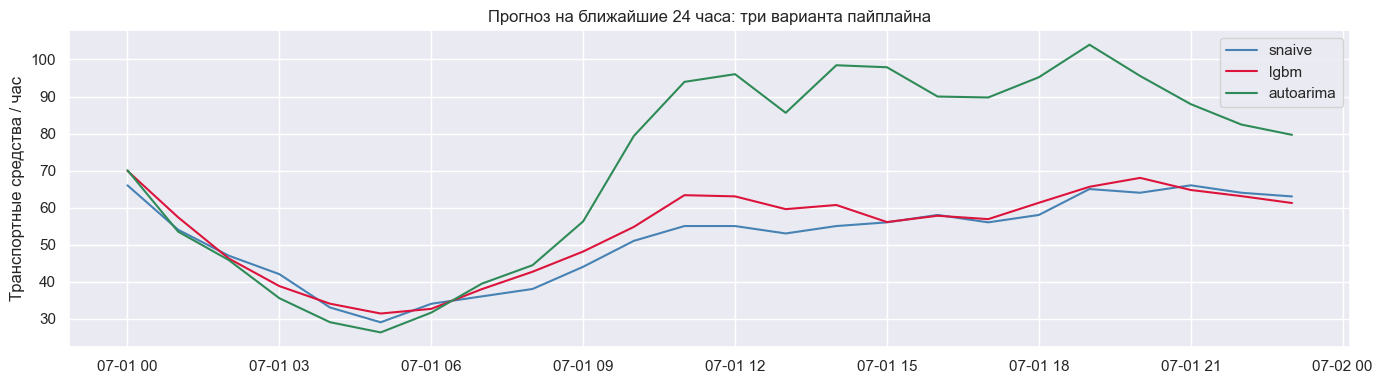

In [63]:
# Визуальное сравнение: прогнозы всех трёх пайплайнов на горизонте 24 часа
preds_joined = None
for model_name in ['snaive', 'lgbm', 'autoarima']:
    p = pd.read_csv(project_root / 'results' / f'forecast_{model_name}.csv', parse_dates=['ds'])
    p = p.rename(columns={'y_hat': model_name})
    if preds_joined is None:
        preds_joined = p[['ds', model_name]]
    else:
        preds_joined = preds_joined.merge(p[['ds', model_name]], on='ds')

fig, ax = plt.subplots(figsize=(14, 4))
for col, color in zip(['snaive', 'lgbm', 'autoarima'], ['steelblue', 'crimson', 'seagreen']):
    ax.plot(preds_joined['ds'], preds_joined[col], label=col, color=color, linewidth=1.5)
ax.set_title('Прогноз на ближайшие 24 часа: три варианта пайплайна')
ax.set_ylabel('Транспортные средства / час')
ax.legend()
plt.tight_layout()
plt.show()

### 7.3 Выводы по пайплайну

- Весь пайплайн — это один файл `src/pipeline.py` с CLI, его одинаково удобно
  гонять и из ноутбука, и из терминала.
- По умолчанию стоит `lgbm`: в разделах 3–5 он дал лучший баланс точности и
  скорости.
- В `bench_df` видно цену каждого варианта: SeasonalNaive — доли секунды,
  LightGBM — единицы секунд, AutoARIMA — десятки секунд или минуты даже на
  урезанной истории.
- Если прогноз надо пересчитывать каждый час, LightGBM подходит лучше всего:
  обучается быстро и при этом заметно точнее сезонного бейзлайна.